#### Inisialisasi Environment and Load Data

In [ ]:
# Import core dependencies 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  
import pickle

# Set aesthetics for plotting 
sns.set_theme(style="darkgrid") 
import warnings 
warnings.filterwarnings('ignore') 

# Load the dataset (Modify the path according to your environment) 
train_path = 'Data/train.csv' 
test_path = 'Data/test.csv' 
df_train = pd.read_csv(train_path) 
df_test = pd.read_csv(test_path) 
print(f"Train set shape: {df_train.shape}") 
print(f"Test set shape: {df_test.shape}")

Train set shape: (594194, 21)
Test set shape: (254655, 20)


#### Inspeksi Data Awal & EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

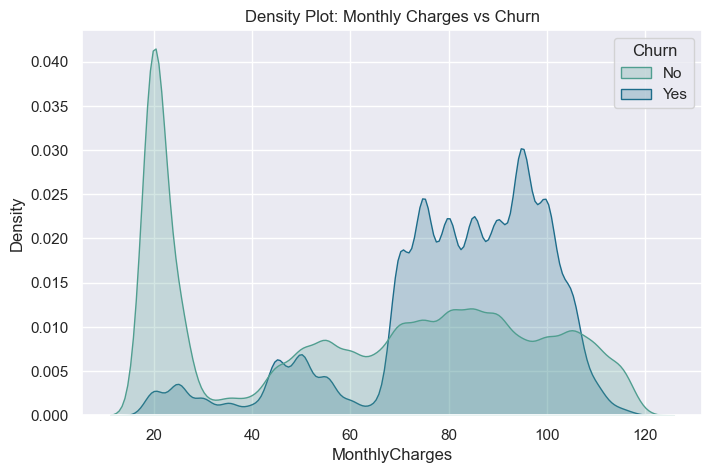

In [2]:
# 1. Structural Inspection
df_train.info()

# 2.Target Class Distribution (imbalance check)
target_distribution = df_train['Churn'].value_counts(normalize=True)*100
print("\nTarget Class Distribution (%):")
print(target_distribution)

# 3.Visualizing Numeric Feature agains Target
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_train, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='crest') 
plt.title('Density Plot: Monthly Charges vs Churn') 
plt.show()

#### Data Cleaning

In [3]:
from sklearn.impute import SimpleImputer 

# 1. Drop identifier column 
df_train_clean = df_train.drop(columns=['id']) 
df_test_clean = df_test.drop(columns=['id']) 

# 2. Type casting anomaly fix: Convert TotalCharges to numeric, coercing spaces to NaN 
df_train_clean['TotalCharges'] = pd.to_numeric(df_train_clean['TotalCharges'], errors='coerce') 
df_test_clean['TotalCharges'] = pd.to_numeric(df_test_clean['TotalCharges'], errors='coerce') 

# 3. Impute emergent NaN values with the median 
imputer = SimpleImputer(strategy='median') 
df_train_clean['TotalCharges'] = imputer.fit_transform(df_train_clean[['TotalCharges']]) 
df_test_clean['TotalCharges'] = imputer.transform(df_test_clean[['TotalCharges']]) 
print(f"Remaining nulls in TotalCharges: {df_train_clean['TotalCharges'].isnull().sum()}") 


Remaining nulls in TotalCharges: 0


#### Feature Encoding & Scaling

In [4]:
from sklearn.preprocessing import StandardScaler  

# Isolate features and target 
X_train = df_train_clean.drop(columns=['Churn']) 
y_train = df_train_clean['Churn'] 
X_test = df_test_clean.copy() 

# 1. Categorical Encoding (One-Hot Encoding with Dummy Variable Trap avoidance) 
cat_features = X_train.select_dtypes(include=['object']).columns 
X_train_enc = pd.get_dummies(X_train, columns=cat_features, drop_first=True) 
X_test_enc = pd.get_dummies(X_test, columns=cat_features, drop_first=True) 

# Align columns to ensure test set matches train set dimensions 
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0) 

# 2. Feature Scaling (Standardization) 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train_enc) 
X_test_scaled = scaler.transform(X_test_enc) 

# Reconstruct DataFrames 
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_enc.columns) 
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_enc.columns) 
print("Data preprocessing completed successfully. Matrix is ready for modeling.") 

Data preprocessing completed successfully. Matrix is ready for modeling.


#### Latihan 1 : EDA Lanjutan (Kategori Biraviat)

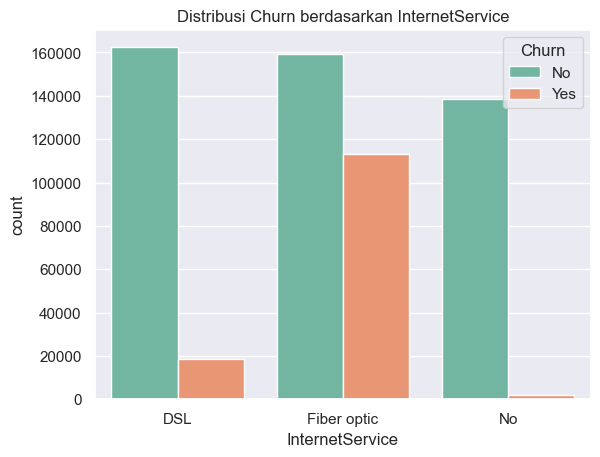

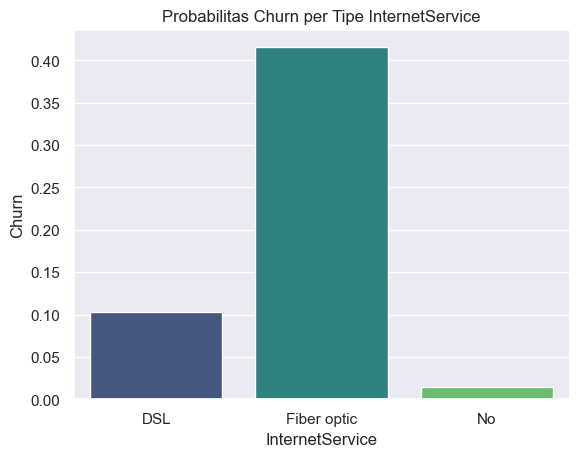

In [5]:
# Nested Bar Plot
sns.countplot(data=df_train, x='InternetService', hue='Churn', palette='Set2')
plt.title('Distribusi Churn berdasarkan InternetService')
plt.show()

# Probabilitas Churn
churn_prob = df_train.groupby('InternetService')['Churn'].agg(lambda x: (x == 'Yes').mean()).reset_index()
sns.barplot(data=churn_prob, x='InternetService', y='Churn', palette='viridis')
plt.title('Probabilitas Churn per Tipe InternetService')
plt.show()

#### Latihan 2 : Rekayasa Fitur (Feature Engineering)

In [6]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df_train_clean['TotalServices'] = df_train_clean[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)
df_test_clean['TotalServices'] = df_test_clean[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)

print("TotalServices berhasil dibuat!")
print(df_train_clean['TotalServices'].value_counts().sort_index())

TotalServices berhasil dibuat!
TotalServices
0    203853
1     75363
2     81929
3     79585
4     64692
5     49277
6     39495
Name: count, dtype: int64


#### Latihan 3 : Eksperimen Scaling (Min-Max Normalization)

In [7]:
from sklearn.preprocessing import MinMaxScaler

# 1. Inisialisasi Scaler
scaler_minmax = MinMaxScaler()

# 2. Tentukan fitur numerik kontinyu yang akan di-scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 3. Terapkan Scaling pada dataframe
df_train_clean[num_cols] = scaler_minmax.fit_transform(df_train_clean[num_cols])

# 4. Tampilkan HASIL dalam bentuk TABEL (Head)
print("# Tampilan 5 data pertama setelah Min-Max Scaling:")
display(df_train_clean[num_cols].head())

# 5. Tampilkan STATISTIK (untuk membuktikan Min=0 dan Max=1)
print("\n# Statistik deskriptif untuk memastikan rentang 0 - 1:")
display(df_train_clean[num_cols].describe().loc[['min', 'max']])

# Tampilan 5 data pertama setelah Min-Max Scaling:


,tenure,MonthlyCharges,TotalCharges
0,0.394366,0.416418,0.188674
1,0.802817,0.509950,0.433810
2,0.802817,0.817413,0.671884
3,0.000000,0.511940,0.005989
4,0.000000,0.519403,0.005960



# Statistik deskriptif untuk memastikan rentang 0 - 1:


,tenure,MonthlyCharges,TotalCharges
min,0.0,0.0,0.0
max,1.0,1.0,1.0


#### Latihan 4 : Jebakan Multikolinearitas (Dummy Variable Tap )

In [8]:
# Demonstrasi Dummy Trap (gender)
gender_no_drop = pd.get_dummies(df_train_clean['gender'], prefix='gender', drop_first=False)
print("Korelasi gender_Female vs gender_Male (Dummy Trap):")
print(gender_no_drop.corr().round(2))

# Scaling
X_train = X_train_enc
y_train = df_train_clean['Churn']
X_test = X_test_enc

scaler_std = StandardScaler()
X_train_final = pd.DataFrame(scaler_std.fit_transform(X_train), columns=X_train.columns)
X_test_final = pd.DataFrame(scaler_std.transform(X_test), columns=X_test.columns)

print("✅ Scaling selesai (StandardScaler)")

Korelasi gender_Female vs gender_Male (Dummy Trap):
               gender_Female  gender_Male
gender_Female            1.0         -1.0
gender_Male             -1.0          1.0
✅ Scaling selesai (StandardScaler)


#### Latihan 5 : Evaluasi & Pemilihan Teknik Encoding Kategorikal

In [10]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Proses Encoding (Ini merubah isi df_train_clean sesungguhnya)
contract_order = ['Month-to-month', 'One year', 'Two year']
ordinal_enc = OrdinalEncoder(categories=[contract_order])
df_train_clean['Contract_Ord'] = ordinal_enc.fit_transform(df_train_clean[['Contract']])

# 2. Mengambil sampel ASLI dari data untuk ditampilkan
# Kita cari baris pertama yang berisi 'One year', 'Two year', dan 'Month-to-month'
sample_one = df_train_clean[df_train_clean['Contract'] == 'One year'].head(1)
sample_two = df_train_clean[df_train_clean['Contract'] == 'Two year'].head(1)
sample_month = df_train_clean[df_train_clean['Contract'] == 'Month-to-month'].head(1)

# 3. Gabungkan sampel tersebut menjadi tabel ringkasan
hasil_display = pd.concat([sample_one, sample_two, sample_month])

# 4. Tampilkan hanya kolom yang relevan dan reset index agar 0, 1, 2
print("# Tampilkan hasil encoding contract (Data Asli dari Dataframe)")
print(hasil_display[['Contract', 'Contract_Ord']].reset_index(drop=True))
df_train_clean['Contract_Ord'] = ordinal_enc.fit_transform(df_train_clean[['Contract']])


# Tampilkan hasil encoding contract (Data Asli dari Dataframe)
         Contract  Contract_Ord
0        One year           1.0
1        Two year           2.0
2  Month-to-month           0.0


#### Latihan 6 : Export Matriks Data Akhir

In [12]:
import pickle

X_train_final.to_csv('TrainWorking/X_train_final.csv', index=False)
y_train.to_csv('TrainWorking/y_train.csv', index=False)
X_test_final.to_csv('TrainWorking/X_test_final.csv', index=False)

with open('TrainWorking/standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('TrainWorking/ordinal_encoder_contract.pkl', 'wb') as f:
    pickle.dump(ordinal_enc, f)
with open('TrainWorking/minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_minmax, f)

print("Export successful!")
print(f"X_train_final shape : {X_train_final.shape}")
print(f"X_test_final shape  : {X_test_final.shape}")
print(f"y_train shape        : {y_train.shape}")

Export successful!
X_train_final shape : (594194, 30)
X_test_final shape  : (254655, 30)
y_train shape        : (594194,)
